# Notebook 4: NDVI Analysis

## Landslide Hazard Zonation using Remote Sensing and GIS

### Objective

This notebook calculates the **Normalized Difference Vegetation Index (NDVI)** from Sentinel-2 imagery.

NDVI is one of the most important conditioning factors for landslide susceptibility because vegetation helps stabilize slopes, reduce erosion, and improve soil cohesion.

### Outputs

- NDVI Raster
- NDVI Map
- NDVI Statistics
- NDVI Classification

In [1]:
!pip install rasterio -q

In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import os

import numpy as np
import matplotlib.pyplot as plt

import rasterio

plt.rcParams["figure.figsize"] = (10,8)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# Project Directories
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

SENTINEL_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "sentinel2"
)

OUTPUT_RASTERS = os.path.join(
    PROJECT_DIR,
    "outputs",
    "rasters"
)

OUTPUT_FIGURES = os.path.join(
    PROJECT_DIR,
    "outputs",
    "figures"
)

print("Project directories loaded successfully!")

Project directories loaded successfully!


In [5]:
import os

NDVI_PATH = os.path.join(
    PROJECT_DIR,
    "outputs",
    "rasters",
    "NDVI_2024_03_31.tif"
)

print(NDVI_PATH)
print(os.path.exists(NDVI_PATH))

/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/NDVI_2024_03_31.tif
True


In [6]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open(NDVI_PATH) as src:
    ndvi = src.read(1)
    profile = src.profile

print(profile)
print("Shape:", ndvi.shape)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 8629, 'height': 11986, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32643"]]'), 'transform': Affine(10.0, 0.0, 678670.0,
       0.0, -10.0, 1145660.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
Shape: (11986, 8629)


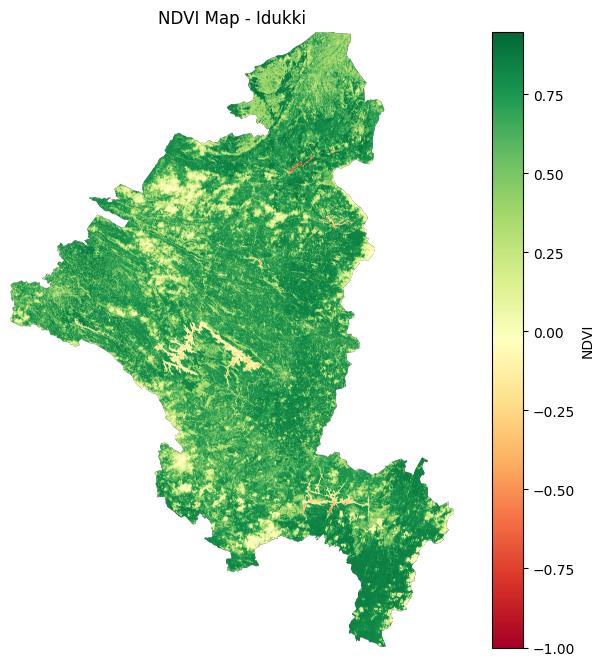

In [7]:
plt.figure(figsize=(10,8))

plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='NDVI')

plt.title("NDVI Map - Idukki")
plt.axis('off')

plt.show()

In [8]:
import numpy as np

# Remove NaN values
ndvi_valid = ndvi[np.isfinite(ndvi)]

print(f"Minimum NDVI : {ndvi_valid.min():.4f}")
print(f"Maximum NDVI : {ndvi_valid.max():.4f}")
print(f"Mean NDVI    : {ndvi_valid.mean():.4f}")
print(f"Std Dev      : {ndvi_valid.std():.4f}")

Minimum NDVI : -1.0000
Maximum NDVI : 0.9493
Mean NDVI    : 0.6116
Std Dev      : 0.2393


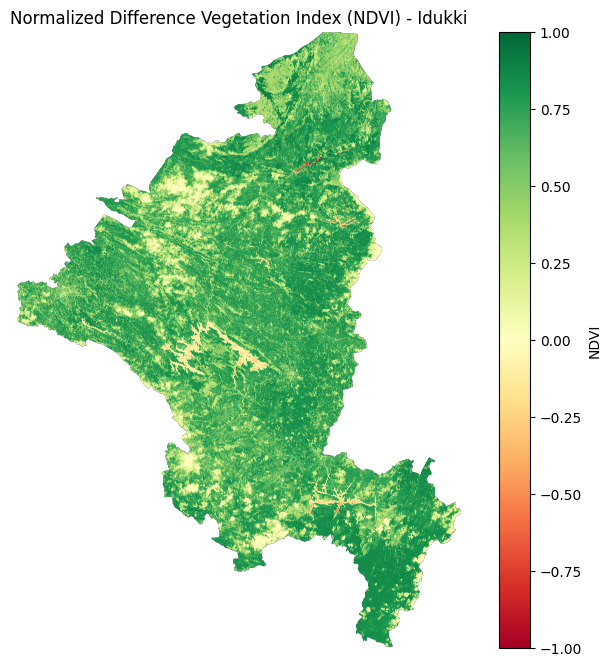

Saved: /content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/ndvi_map.png


In [9]:
figure_path = os.path.join(
    OUTPUT_FIGURES,
    "ndvi_map.png"
)

plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")

plt.title("Normalized Difference Vegetation Index (NDVI) - Idukki")
plt.axis("off")

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print("Saved:", figure_path)